# Olist E-commerce: Delivery Performance and Low Review Risk

This notebook extends the SQL analysis of the Olist e-commerce dataset with Python. The analysis focuses on whether delivery performance and order characteristics are associated with low customer reviews.

**Unit of analysis:** one delivered order.

**Low review definition:** `review_score <= 2`.

> The logistic regression in this notebook is best interpreted as a **post-fulfillment risk/diagnostic model**, because `delivery_days` and `delay_days` require the actual delivery date. It is not a pre-delivery forecasting model.


In [1]:
from getpass import getpass

import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load order-level data from PostgreSQL

The password is requested interactively so that no database credential is stored in the notebook or exposed on GitHub.


In [3]:
conn = psycopg2.connect(
    host="localhost",
    port="5432",
    database="olist_ecommerce",
    user="postgres",
    password=getpass("PostgreSQL password: ")
)

PostgreSQL password: ········


The SQL below first aggregates `order_items` and `reviews` to the `order_id` level, then joins them to orders and customers. This avoids inflating rows when an order contains multiple items or review records.


In [ ]:
query = """
WITH item_summary AS (
    SELECT
        order_id,
        SUM(price) AS order_total,
        SUM(freight_value) AS freight_total,
        COUNT(*) AS num_items,
        COUNT(DISTINCT product_id) AS num_products
    FROM order_items
    GROUP BY order_id
),

review_summary AS (
    SELECT
        order_id,
        AVG(review_score) AS review_score
    FROM reviews
    GROUP BY order_id
)

SELECT
    o.order_id,
    c.customer_unique_id,
    c.customer_state,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    i.order_total,
    i.freight_total,
    i.num_items,
    i.num_products,
    r.review_score
FROM orders o
INNER JOIN customers c
    ON o.customer_id = c.customer_id
INNER JOIN item_summary i
    ON o.order_id = i.order_id
LEFT JOIN review_summary r
    ON o.order_id = r.order_id
WHERE o.order_status = 'delivered';
"""

df = pd.read_sql_query(query, conn)

## 2. Validate the analysis dataset

Check the first rows, shape, data types, and missing values before creating features.


In [5]:
df.head()

,order_id,customer_unique_id,customer_state,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,order_total,freight_total,num_items,num_products,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,RJ,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,58.90,13.29,1,1,5.0
1,00054e8431b9d7675808bcb819fb4a32,635d9ac1680f03288e72ada3a1035803,SP,2017-12-10 11:53:48,2017-12-18 22:03:38,2018-01-04,19.90,11.85,1,1,4.0
2,000576fe39319847cbb9d288c5617fa6,fda4476abb6307ab3c415b7e6d026526,SP,2018-07-04 12:08:27,2018-07-09 14:04:07,2018-07-25,810.00,70.75,1,1,5.0
3,0005a1a1728c9d785b8e2b08b904576c,639d23421f5517f69d0c3d6e6564cf0e,SP,2018-03-19 18:40:33,2018-03-29 18:17:31,2018-03-29,145.95,11.65,1,1,1.0
4,00061f2a7bc09da83e415a52dc8a4af1,107e6259485efac66428a56f10801f4f,SP,2018-03-24 22:16:10,2018-03-29 00:04:19,2018-04-09,59.99,8.88,1,1,5.0


In [6]:
df.shape

(96478, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96478 non-null  object        
 1   customer_unique_id             96478 non-null  object        
 2   customer_state                 96478 non-null  object        
 3   order_purchase_timestamp       96478 non-null  datetime64[ns]
 4   order_delivered_customer_date  96470 non-null  datetime64[ns]
 5   order_estimated_delivery_date  96478 non-null  datetime64[ns]
 6   order_total                    96478 non-null  float64       
 7   freight_total                  96478 non-null  float64       
 8   num_items                      96478 non-null  int64         
 9   num_products                   96478 non-null  int64         
 10  review_score                   95832 non-null  float64       
dtypes: datetime64[n

In [8]:
df.isna().sum()

order_id                           0
customer_unique_id                 0
customer_state                     0
order_purchase_timestamp           0
order_delivered_customer_date      8
order_estimated_delivery_date      0
order_total                        0
freight_total                      0
num_items                          0
num_products                       0
review_score                     646
dtype: int64

The query returns **96,478 delivered orders** and 11 columns. Delivery timestamps are missing for only 8 delivered orders, while `review_score` is missing for 646 orders. These missing values are handled later with `dropna()` only for modeling rows that require them.


## 3. Feature engineering

Create variables that summarize fulfillment performance, shipping cost burden, and the binary low-review target.

- `delivery_days`: days from purchase to actual delivery.
- `delay_days`: actual delivery date minus estimated delivery date. Positive values mean late delivery; negative values mean early delivery.
- `freight_ratio`: freight cost divided by merchandise value.
- `low_review`: 1 for review scores 1–2, 0 for scores 3–5.


In [9]:
# How many days the order took to arrive
df["delivery_days"] = (
    df["order_delivered_customer_date"]
    - df["order_purchase_timestamp"]
).dt.total_seconds() / 86400

# Positive = late, negative = arrived early
df["delay_days"] = (
    df["order_delivered_customer_date"]
    - df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

# Freight cost relative to merchandise value
df["freight_ratio"] = (
    df["freight_total"] / df["order_total"]
)

# Binary target for later modeling
df["low_review"] = np.where(
    df["review_score"].isna(),
    np.nan,
    (df["review_score"] <= 2).astype(int)
)

## 4. Exploratory analysis

Start with descriptive statistics and compare low-review orders with other reviewed orders.


In [10]:
df[
    [
        "order_total",
        "freight_total",
        "num_items",
        "num_products",
        "delivery_days",
        "delay_days",
        "review_score"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
order_total,96478.0,137.041586,209.045198,0.850000,45.900000,86.575000,149.900000,13440.000000
freight_total,96478.0,22.785253,21.559197,0.000000,13.850000,17.170000,24.017500,1794.960000
num_items,96478.0,1.142198,0.538804,1.000000,1.000000,1.000000,1.000000,21.000000
num_products,96478.0,1.038537,0.227942,1.000000,1.000000,1.000000,1.000000,8.000000
delivery_days,96470.0,12.558217,9.546156,0.533414,6.766204,10.217477,15.720182,209.628611
delay_days,96470.0,-11.178126,10.184354,-146.016123,-16.244065,-11.948102,-6.389815,188.975081
review_score,95832.0,4.156187,1.283622,1.000000,4.000000,5.000000,5.000000,5.000000


In [11]:
df["low_review"].value_counts()

low_review
0.0    83595
1.0    12237
Name: count, dtype: int64

In [12]:
df["low_review"].value_counts(normalize=True)

low_review
0.0    0.872308
1.0    0.127692
Name: proportion, dtype: float64

In [13]:
df.groupby("low_review")[
    ["order_total", "freight_total", "num_items",
     "delivery_days", "delay_days"]
].mean()

,order_total,freight_total,num_items,delivery_days,delay_days
low_review,,,,,
0.0,133.379056,22.035955,1.115605,11.388672,-12.209252
1.0,160.183986,27.724441,1.316581,20.223127,-4.424619


In [14]:
df.groupby("low_review")[
    ["order_total", "freight_total", "num_items",
     "delivery_days", "delay_days"]
].median()

,order_total,freight_total,num_items,delivery_days,delay_days
low_review,,,,,
0.0,84.9,16.94,1.0,9.876059,-12.187708
1.0,98.0,18.51,1.0,15.720938,-7.244115


### EDA takeaways

Low reviews account for about **12.8%** of reviewed delivered orders. Low-review orders have longer delivery times: the median is about **15.7 days**, compared with about **9.9 days** for other reviewed orders. Mean values tell the same general story, although delivery variables contain some extreme observations, so medians are useful alongside means.


## 5. Delivery status and low-review rate

Convert `delay_days` into a simple late/on-time indicator, preserving missing delivery dates as missing rather than automatically treating them as on time.


In [15]:
df["is_late"] = np.where(
    df["delay_days"].isna(),
    np.nan,
    (df["delay_days"] > 0).astype(int)
)

In [16]:
df.groupby("is_late")["low_review"].mean()

is_late
0.0    0.091875
1.0    0.539877
Name: low_review, dtype: float64

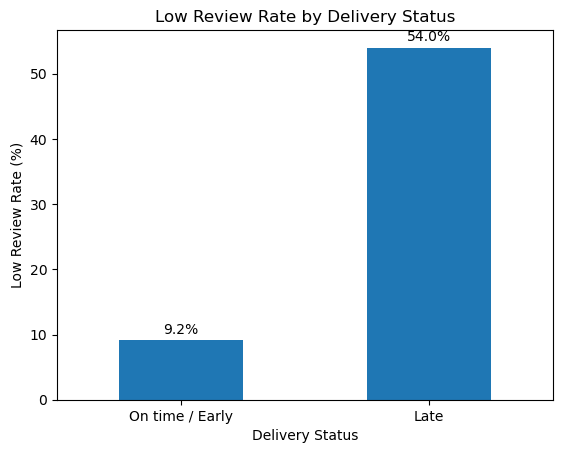

In [17]:
late_review_rate = (
    df.groupby("is_late")["low_review"]
      .mean()
      .mul(100)
)

late_review_rate.index = ["On time / Early", "Late"]

ax = late_review_rate.plot(kind="bar")

plt.ylabel("Low Review Rate (%)")
plt.xlabel("Delivery Status")
plt.title("Low Review Rate by Delivery Status")
plt.xticks(rotation=0)

for i, value in enumerate(late_review_rate):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.show()

Late delivery is strongly associated with low ratings in this dataset: the low-review rate is about **54.0% for late orders** versus about **9.2% for orders delivered on time or early**. This is an association, not evidence that delay is the sole causal mechanism behind the review.


## 6. Logistic regression: low-review risk

Use a logistic regression baseline to test whether order and delivery features can distinguish low-review orders from other reviewed orders.

Features:
`delay_days`, `delivery_days`, `order_total`, `freight_ratio`, `num_items`, and `num_products`.

The train/test split is stratified because low reviews make up only about 12.8% of reviewed orders.


In [18]:
features = [
    "delay_days",
    "delivery_days",
    "order_total",
    "freight_ratio",
    "num_items",
    "num_products"
]

model_df = df[features + ["low_review"]].dropna()

model_df.shape

(95824, 7)

In [19]:
X = model_df[features]
y = model_df["low_review"].astype(int)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline



In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg', LogisticRegression(max_iter=1000))])

In [23]:
model.score(X_test, y_test)

0.8828593790764414

In [24]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[16561   157]
 [ 2088   359]]
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     16718
           1       0.70      0.15      0.24      2447

    accuracy                           0.88     19165
   macro avg       0.79      0.57      0.59     19165
weighted avg       0.86      0.88      0.85     19165

ROC-AUC: 0.7241505317687724


### Baseline model result

The unweighted logistic regression achieves about **0.73 ROC-AUC**, but its recall for low reviews is only **0.16**. Accuracy is about 0.89, but accuracy is not very informative here because the target is imbalanced.


## 7. Class-balanced logistic regression

To reduce the model's tendency to predict the majority class, fit a second logistic regression with `class_weight="balanced"`.


In [25]:
balanced_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

balanced_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [26]:
y_pred_balanced = balanced_model.predict(X_test)
y_prob_balanced = balanced_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_balanced))

[[13259  3459]
 [ 1033  1414]]
              precision    recall  f1-score   support

           0       0.93      0.79      0.86     16718
           1       0.29      0.58      0.39      2447

    accuracy                           0.77     19165
   macro avg       0.61      0.69      0.62     19165
weighted avg       0.85      0.77      0.80     19165

ROC-AUC: 0.7293746947183631


The balanced model raises low-review recall from **0.16 to 0.58**, while precision falls to **0.29** and accuracy to about **0.76**. ROC-AUC remains around **0.73**. This tradeoff is more suitable when the goal is to flag a larger share of potentially dissatisfied customers for follow-up.


## 8. Model interpretation

Because the predictors are standardized inside the pipeline, coefficient magnitudes can be compared cautiously. Positive coefficients are associated with higher modeled low-review risk; negative coefficients are associated with lower modeled risk.


In [27]:
coef = pd.DataFrame({
    "feature": features,
    "coefficient": balanced_model.named_steps["logreg"].coef_[0]
})

coef.sort_values("coefficient", ascending=False)

,feature,coefficient
1,delivery_days,0.604091
4,num_items,0.319123
0,delay_days,0.296082
5,num_products,0.199044
2,order_total,0.025488
3,freight_ratio,-0.012074


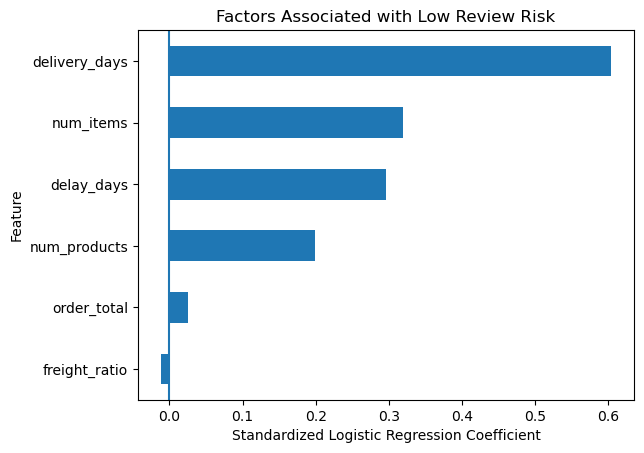

In [28]:
coef_sorted = coef.sort_values("coefficient")

ax = coef_sorted.plot(
    x="feature",
    y="coefficient",
    kind="barh",
    legend=False
)

plt.xlabel("Standardized Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Factors Associated with Low Review Risk")
plt.axvline(0)
plt.show()

`delivery_days` has the largest positive standardized coefficient, followed by `num_items` and `delay_days`. `order_total` and `freight_ratio` add little signal in this specification.

Coefficient magnitudes should not be interpreted as causal effects or as independent feature importance because some predictors are correlated.


In [29]:
model_df[features].corr().round(2)

,delay_days,delivery_days,order_total,freight_ratio,num_items,num_products
delay_days,1.00,0.60,-0.01,-0.03,-0.03,-0.05
delivery_days,0.60,1.00,0.06,0.08,-0.02,-0.03
order_total,-0.01,0.06,1.00,-0.30,0.15,0.06
freight_ratio,-0.03,0.08,-0.30,1.00,0.07,0.01
num_items,-0.03,-0.02,0.15,0.07,1.00,0.48
num_products,-0.05,-0.03,0.06,0.01,0.48,1.00


The strongest predictor correlations are approximately **0.60 between `delivery_days` and `delay_days`** and **0.48 between `num_items` and `num_products`**. This overlap is another reason to interpret individual logistic coefficients cautiously.


## 9. Key findings

1. **Low reviews are a minority class:** about 12.8% of reviewed delivered orders receive scores of 1–2.
2. **Delivery performance is the clearest business signal:** late orders have a low-review rate of about 54.0%, compared with about 9.2% for on-time or early orders.
3. **Low-review orders take longer to arrive:** median delivery time is about 15.7 days versus 9.9 days for other reviewed orders.
4. **The simple model has moderate discrimination:** ROC-AUC is about 0.73.
5. **Class balancing improves detection:** low-review recall rises from 16% to 58%, at the cost of lower precision and overall accuracy.
6. **Delivery-related variables show the strongest model association**, while order value and freight ratio contribute relatively little additional signal.

## 10. Limitations

- The analysis is observational, so associations should not be interpreted as causal effects.
- The model uses actual delivery outcomes, so it is a post-fulfillment diagnostic/risk-scoring model rather than a pre-delivery prediction system.
- Product category, seller characteristics, geography beyond state, customer history, and review text are not included in the model.
- The target is imbalanced, so precision, recall, F1, and ROC-AUC are more informative than accuracy alone.
